In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


> **Species–vegetation refinement (added):** After the species-level heatmap and Summary A/B/C cells, this notebook continues with **p-values, FDR (`q`), log1p NDVI, Kruskal–Wallis**, `species_veg_detail_df`, and diagnostic plots. Scroll to the **last cells** or search for `Further refinement` / `species_veg_detail_df`.


In [49]:
df = pd.read_csv('file6.csv')

In [50]:
df.head()

,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,NDVI_raw,LandCover_Class,...,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation,lka_general_2020,NDVI
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.85502,2021-01-06,0.66,3792.0,10,...,3.372161e-09,3.725563e-08,0.175115,26.58,15.17,1.31,85.53,17.65,2.805795,0.3792
1,2,Hirundo rustica,Colombo,10.0,6.866285,79.93144,2024-12-23,10.16,7045.0,13,...,4.424376e-09,3.249729e-08,0.198127,26.21,0.25,2.51,84.30,20.49,8.917330,0.7045
2,6,Corvus macrorhynchos,Matara,2.0,5.983496,80.52548,2024-10-12,1.26,6989.0,10,...,7.456183e-10,5.362027e-08,0.131458,26.91,14.47,5.18,83.81,15.67,2.768103,0.6989
3,7,Dicrurus caerulescens,Matale,1.0,7.969125,80.75477,2021-11-20,0.37,8543.0,8,...,1.612494e-09,3.017664e-08,0.123156,25.30,2.54,2.98,89.54,21.99,3.339740,0.8543
4,8,Threskiornis melanocephalus,Jaffna,30.0,9.637712,79.95190,2019-03-25,0.52,4000.0,10,...,2.737918e-09,3.224930e-08,0.220155,29.67,0.00,4.65,63.33,24.53,3.209018,0.4000


In [51]:
df.shape

(1552048, 24)

In [52]:
df.columns

Index(['index', 'verbatimScientificName', 'stateProvince', 'individualCount',
       'decimalLatitude', 'decimalLongitude', 'eventDate', 'avg_rad',
       'NDVI_raw', 'LandCover_Class', 'elevation_meters', 'Carbon_Mass',
       'Dust_Mass', 'SO2_Mass', 'Sulfate_Mass', 'Sea_Salt_Mass',
       'Total_Aerosol_Extinction', 'temp_mean', 'rainfall', 'wind_mean',
       'humid_mean', 'shortwave_radiation', 'lka_general_2020', 'NDVI'],
      dtype='object')

In [53]:
cols = [
    "individualCount", "NDVI_raw", "LandCover_Class",
    "verbatimScientificName", "decimalLatitude", "decimalLongitude", 'eventDate'
]

d = df[cols].copy()
d["NDVI"] = pd.to_numeric(d["NDVI_raw"], errors="coerce") / 10000

### NDVI_raw - Raw Normalized Difference Vegetation Index (scaled for storage)	Dimensionless (-10000 to +10000)
### NDVI - True calculated vegetation greenness (NDVI_raw / 10000)	Dimensionless (-1.0 to 1.0)

In [54]:
# < 0.0: Deep water bodies, oceans, or severe cloud interference.
# 0.0 to 0.1: Barren areas of rock, sand, snow, or dense concrete (Urban cores).
# 0.2 to 0.4: Sparse vegetation, dry scrublands, or bare soil.
# 0.5 to 0.7: Moderate vegetation, active agricultural croplands, or mixed forests.
# 0.8 to 1.0: Dense, healthy, wet canopy vegetation (e.g., Evergreen Rainforests).

In [55]:
d.head()

,individualCount,NDVI_raw,LandCover_Class,verbatimScientificName,decimalLatitude,decimalLongitude,eventDate,NDVI
0,8.0,3792.0,10,Anarhynchus alexandrinus,9.058512,79.85502,2021-01-06,0.3792
1,10.0,7045.0,13,Hirundo rustica,6.866285,79.93144,2024-12-23,0.7045
2,2.0,6989.0,10,Corvus macrorhynchos,5.983496,80.52548,2024-10-12,0.6989
3,1.0,8543.0,8,Dicrurus caerulescens,7.969125,80.75477,2021-11-20,0.8543
4,30.0,4000.0,10,Threskiornis melanocephalus,9.637712,79.95190,2019-03-25,0.4000


In [56]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552048 entries, 0 to 1552047
Data columns (total 8 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   individualCount         1552048 non-null  float64
 1   NDVI_raw                1552048 non-null  float64
 2   LandCover_Class         1552048 non-null  int64  
 3   verbatimScientificName  1552048 non-null  object 
 4   decimalLatitude         1552048 non-null  float64
 5   decimalLongitude        1552048 non-null  float64
 6   eventDate               1552048 non-null  object 
 7   NDVI                    1552048 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 94.7+ MB


In [57]:
d.isnull().sum()

individualCount           0
NDVI_raw                  0
LandCover_Class           0
verbatimScientificName    0
decimalLatitude           0
decimalLongitude          0
eventDate                 0
NDVI                      0
dtype: int64

In [58]:
# As there are 81102 null values in NDVI, we will drop those rows for our analysis
d = d.dropna(subset=["NDVI"])

In [59]:
d.shape

(1552048, 8)

In [60]:
d.isnull().sum()

individualCount           0
NDVI_raw                  0
LandCover_Class           0
verbatimScientificName    0
decimalLatitude           0
decimalLongitude          0
eventDate                 0
NDVI                      0
dtype: int64

### Correlation between individualCount and NDVI

##### pearsonr - Measures linear correlation between two variables
##### spearmanr - Measures rank/monotonic correlation

In [61]:
from scipy.stats import pearsonr, spearmanr, kruskal

r_p, p_p = pearsonr(d["individualCount"], d["NDVI"])
r_s, p_s = spearmanr(d["individualCount"], d["NDVI"])

# r_p → correlation value
# p_p → p-value (statistical significance)

print("Count vs NDVI")
print(f"Pearson r = {r_p:.3f}, p = {p_p:.4g}")
print(f"Spearman rho = {r_s:.3f}, p = {p_s:.4g}")

Count vs NDVI
Pearson r = -0.022, p = 3.05e-158
Spearman rho = -0.094, p = 0


### --------------------------------
##### Pearson correlation showed a very weak negative relationship between NDVI and individual count (r = −0.020, p < 0.001). Spearman correlation also indicated a weak negative association (ρ = −0.083, p < 0.001). Despite statistical significance due to the large sample size, the effect size is negligible, suggesting NDVI alone is not a strong predictor of individual abundance.
### --------------------------------

##### As NDVI data alone does not have any significant correlation, lets use LandCover_Class also to see the correlation with vegetation and bird count.

##### Here there are 17 landcover classes,
 ##### 1     Evergreen Needleleaf Forest      
 ##### 2     Evergreen Broadleaf Forest       
 ##### 3     Deciduous Needleleaf Forest        
 ##### 4     Deciduous Broadleaf Forest         
 ##### 5     Mixed Forest                       
 ##### 6     Closed Shrublands                  
 ##### 7     Open Shrublands                  
 ##### 8     Woody Savannas                   
 ##### 9     Savannas                         
 ##### 10    Grasslands                      
 ##### 11    Permanent Wetlands               
 ##### 12    Croplands                        
 ##### 13    Urban and Built-up             
 ##### 14    Cropland/Natural Vegetation Mosaic 
 ##### 15    Snow and Ice                     
 ##### 16    Barren or Sparsely Vegetated    
 ##### 17    Water Bodies 

In [62]:
# Count differences across land cover classes

# This code groups the dataset by land cover class and collects the corresponding 
# individualCount values for each group. It then applies the non-parametric Kruskal–Wallis 
# test using SciPy to determine whether the distribution of individual counts differs 
# significantly among the different land cover classes. The test returns the statistic 
# H and a p-value indicating statistical significance.

# Kruskal–Wallis Test - It compares the median (typical value) of several groups to see if at 
# least one group is significantly different from the others.


lc_groups = [g["individualCount"].values for _, g in d.groupby("LandCover_Class") if len(g) > 1]
if len(lc_groups) >= 2:
    H, p_kw = kruskal(*lc_groups)
    print(f"Kruskal-Wallis for count across LandCover_Class: H = {H:.3f}, p = {p_kw:.4g}")


Kruskal-Wallis for count across LandCover_Class: H = 20784.818, p = 0


##### The number of individuals is significantly different across different LandCover_Class categories, meaning some land cover types have higher or lower counts than others.

### Biodiversity vs vegetation (NDVI, LandCover_Class)

In [63]:
from scipy.stats import spearmanr, kruskal

In [64]:
d_bio = d[["verbatimScientificName", "NDVI", "LandCover_Class", "decimalLatitude", "decimalLongitude", "eventDate"]].copy()
d_bio["NDVI"] = pd.to_numeric(d_bio["NDVI"], errors="coerce")
d_bio["eventDate"] = pd.to_datetime(d_bio["eventDate"], errors="coerce")
d_bio = d_bio.dropna()

d_bio.head()

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.85502,2021-01-06
1,Hirundo rustica,0.7045,13,6.866285,79.93144,2024-12-23
2,Corvus macrorhynchos,0.6989,10,5.983496,80.52548,2024-10-12
3,Dicrurus caerulescens,0.8543,8,7.969125,80.75477,2021-11-20
4,Threskiornis melanocephalus,0.4000,10,9.637712,79.95190,2019-03-25


In [65]:
# Sampling unit: site + month (avoids pooling everything at site level only)
d_bio["site"] = d_bio["decimalLatitude"].round(3).astype(str) + "_" + d_bio["decimalLongitude"].round(3).astype(str)
d_bio["year_month"] = d_bio["eventDate"].dt.to_period("M").astype(str)
d_bio["sample_unit"] = d_bio["site"] + "_" + d_bio["year_month"]

d_bio.head()

# The code creates a unique sampling unit based on location (site) and time (month) so that biodiversity
# observations are analyzed at the site-month level instead of pooling all data from a site together.

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate,site,year_month,sample_unit
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.85502,2021-01-06,9.059_79.855,2021-01,9.059_79.855_2021-01
1,Hirundo rustica,0.7045,13,6.866285,79.93144,2024-12-23,6.866_79.931,2024-12,6.866_79.931_2024-12
2,Corvus macrorhynchos,0.6989,10,5.983496,80.52548,2024-10-12,5.983_80.525,2024-10,5.983_80.525_2024-10
3,Dicrurus caerulescens,0.8543,8,7.969125,80.75477,2021-11-20,7.969_80.755,2021-11,7.969_80.755_2021-11
4,Threskiornis melanocephalus,0.4000,10,9.637712,79.95190,2019-03-25,9.638_79.952,2019-03,9.638_79.952_2019-03


In [66]:
# Per-sample biodiversity metrics
richness = d_bio.groupby("sample_unit")["verbatimScientificName"].nunique().rename("species_richness")

# It groups the dataset by sample_unit (site + month) and counts the number of unique species names 
# (verbatimScientificName) recorded in each unit using nunique(). The result is stored as a new 
# variable called species_richness, which represents the number of different species observed in 
# each sampling unit.


##### The Shannon index is a measure of biodiversity that accounts for both the number of species (richness) and how evenly individuals are distributed among them (evenness). A higher value indicates a more diverse community with many species evenly represented, while a lower value indicates fewer species or dominance by one species.

In [67]:
# Shannon diversity

def shannon_index(species_series):
    counts = species_series.value_counts()  # Count occurrences of each species
    p = counts / counts.sum() # Convert counts to proportions
    return float(-(p * np.log(p)).sum()) # Shannon index formula

shannon = d_bio.groupby("sample_unit")["verbatimScientificName"].apply(shannon_index).rename("shannon")

In [68]:
# Vegetation summary per sample unit

# This code creates a table per site-month combining biodiversity metrics (richness, Shannon index)
# with vegetation data (mean NDVI, dominant land cover) for analysis.

veg = d_bio.groupby("sample_unit").agg(
    mean_ndvi=("NDVI", "mean"), # Average NDVI per unit
    landcover_mode=("LandCover_Class", lambda x: x.mode().iloc[0]) # Most common land cover
)

bio = pd.concat([richness, shannon, veg], axis=1).dropna()

In [69]:
print("Number of sample units:", len(bio))
print("\nBiodiversity summary (first 5 rows):")
print(bio.head())

Number of sample units: 31308

Biodiversity summary (first 5 rows):
                      species_richness   shannon  mean_ndvi  landcover_mode
sample_unit                                                                
5.926_80.585_2024-07                 2  0.693147     0.5768              17
5.927_80.589_2022-01                18  2.890372     0.7170              14
5.927_80.589_2022-08                 5  1.609438     0.4409              14
5.927_80.589_2024-07                14  2.639057     0.5709               9
5.928_80.589_2024-05                 1 -0.000000     0.5562               9


In [70]:
# Correlation with NDVI
rho_r, p_r = spearmanr(bio["species_richness"], bio["mean_ndvi"])
rho_s, p_s_bio = spearmanr(bio["shannon"], bio["mean_ndvi"])

print("\nBiodiversity vs NDVI (Spearman)")
print(f"Richness vs NDVI: rho = {rho_r:.3f}, p = {p_r:.4g}")
print(f"Shannon vs NDVI:  rho = {rho_s:.3f}, p = {p_s_bio:.4g}")


Biodiversity vs NDVI (Spearman)
Richness vs NDVI: rho = 0.033, p = 6.375e-09
Shannon vs NDVI:  rho = 0.039, p = 6.99e-12


##### NDVI shows a very weak positive relationship with both species richness and Shannon diversity; the effect exists statistically but is ecologically minor.

##### Tests whether biodiversity differs across land cover types using the Kruskal–Wallis test.

In [71]:
# Differences across LandCover classes
groups_rich = [g["species_richness"].values for _, g in bio.groupby("landcover_mode") if len(g) > 1]
groups_shan = [g["shannon"].values for _, g in bio.groupby("landcover_mode") if len(g) > 1]

if len(groups_rich) >= 2:
    H_r, p_kw_r = kruskal(*groups_rich)
    print(f"\nKruskal-Wallis for richness across LandCover: H = {H_r:.3f}, p = {p_kw_r:.4g}")
else:
    print("\nNot enough groups for richness Kruskal-Wallis.")

if len(groups_shan) >= 2:
    H_s, p_kw_s = kruskal(*groups_shan)
    print(f"Kruskal-Wallis for Shannon across LandCover: H = {H_s:.3f}, p = {p_kw_s:.4g}")
else:
    print("Not enough groups for Shannon Kruskal-Wallis.")


Kruskal-Wallis for richness across LandCover: H = 294.975, p = 1.793e-57
Kruskal-Wallis for Shannon across LandCover: H = 333.301, p = 1.387e-65


##### Some land cover types support higher biodiversity, while others have lower richness and diversity, and these differences are highly significant.

#### -------------------------

##### The previous Kruskal–Wallis tests only tell you whether there is a general difference among all land cover classes for richness or Shannon diversity—they don’t indicate which specific pairs of classes differ.

##### The Dunn post-hoc test goes a step further and performs pairwise comparisons between every land cover class, showing exactly which pairs are significantly different after correcting for multiple comparisons.

#### -------------------------

In [72]:
import scikit_posthocs as sp


In [73]:
bio_post = bio[["species_richness", "shannon", "landcover_mode"]].dropna().copy()

In [74]:
bio_post.head()

,species_richness,shannon,landcover_mode
sample_unit,,,
5.926_80.585_2024-07,2,0.693147,17
5.927_80.589_2022-01,18,2.890372,14
5.927_80.589_2022-08,5,1.609438,14
5.927_80.589_2024-07,14,2.639057,9
5.928_80.589_2024-05,1,-0.000000,9


In [75]:
bio_post.shape

(31308, 3)

In [76]:
# Richness pairwise LandCover differences
# It tests which specific land cover pairs have significantly different species richness
rich_dunn = sp.posthoc_dunn(
    bio_post,
    val_col="species_richness",
    group_col="landcover_mode",
    p_adjust="holm"
)

In [77]:
# Shannon pairwise LandCover differences
shan_dunn = sp.posthoc_dunn(
    bio_post,
    val_col="shannon",
    group_col="landcover_mode",
    p_adjust="holm"
)

In [78]:
# Helper to extract significant pairwise results

# This converts the Dunn test output into a readable table of only significant pairs, showing which 
# land cover classes differ in biodiversity metrics and by how much.

def extract_sig_pairs(pmat, metric_name, alpha=0.05):
    rows = []
    classes = pmat.index.tolist()
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            p_adj = float(pmat.iloc[i, j])
            if p_adj < alpha:
                a, b = classes[i], classes[j]
                med_a = float(bio_post.loc[bio_post["landcover_mode"] == a, metric_name].median())
                med_b = float(bio_post.loc[bio_post["landcover_mode"] == b, metric_name].median())
                rows.append({
                    "Class_A": a,
                    "Class_B": b,
                    "p_adj": p_adj,
                    "median_A": med_a,
                    "median_B": med_b,
                    "median_diff_A_minus_B": med_a - med_b,
                })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["p_adj", "median_diff_A_minus_B"], ascending=[True, False])
    return out

In [79]:
# This tells you how many land cover pairs differ significantly in biodiversity and gives a 
# quick overview of the post-hoc test results.

rich_sig = extract_sig_pairs(rich_dunn, "species_richness")
shan_sig = extract_sig_pairs(shan_dunn, "shannon")

n_classes = bio_post["landcover_mode"].nunique()
n_pairs = n_classes * (n_classes - 1) // 2

print(f"LandCover classes analyzed: {n_classes}")
print(f"Total pairwise comparisons per metric: {n_pairs}")





LandCover classes analyzed: 11
Total pairwise comparisons per metric: 55


In [80]:
print("\nRichness pairwise LandCover differences")
print(f"Significant pairs after Holm correction: {len(rich_sig)} / {n_pairs}")

if rich_sig.empty:
    print("No significant richness pairs after Holm correction.")
else:
    print("Top 10 most significant richness pairs:")
    print(rich_sig.head(10).to_string(index=False))




Richness pairwise LandCover differences
Significant pairs after Holm correction: 23 / 55
Top 10 most significant richness pairs:
 Class_A  Class_B        p_adj  median_A  median_B  median_diff_A_minus_B
       2        8 2.137466e-32      18.0      13.0                    5.0
       2       14 2.102473e-31      18.0      13.0                    5.0
      10       14 5.280613e-21      19.0      13.0                    6.0
       8       10 5.472698e-21      13.0      19.0                   -6.0
       2       13 1.247908e-19      18.0      14.0                    4.0
       8        9 3.057074e-14      13.0      16.0                   -3.0
       9       14 6.082767e-14      16.0      13.0                    3.0
      10       13 4.034518e-13      19.0      14.0                    5.0
       2       12 1.590667e-07      18.0      14.0                    4.0
       2       11 1.958284e-06      18.0      13.0                    5.0


##### The above table identifies which specific land cover pairs differ significantly in richness and by how much, providing a detailed follow-up to the overall Kruskal-Wallis test.

In [81]:
print("\nShannon pairwise LandCover differences")
print(f"Significant pairs after Holm correction: {len(shan_sig)} / {n_pairs}")
if shan_sig.empty:
    print("No significant shannon pairs after Holm correction.")
else:
    print("Top 10 most significant shannon pairs:")
    print(shan_sig.head(10).to_string(index=False))


Shannon pairwise LandCover differences
Significant pairs after Holm correction: 23 / 55
Top 10 most significant shannon pairs:
 Class_A  Class_B        p_adj  median_A  median_B  median_diff_A_minus_B
       2        8 5.896441e-34  2.890372  2.564949               0.325422
       2       14 6.034384e-33  2.890372  2.564949               0.325422
       2       13 1.107816e-27  2.890372  2.639057               0.251314
      10       14 1.703869e-23  2.890372  2.564949               0.325422
       8       10 1.703869e-23  2.564949  2.890372              -0.325422
      10       13 7.303811e-20  2.890372  2.639057               0.251314
       8        9 2.978702e-15  2.564949  2.715956              -0.151006
       9       14 6.111536e-15  2.715956  2.564949               0.151006
       9       13 7.537395e-11  2.715956  2.639057               0.076898
       2       12 3.515052e-07  2.890372  2.617732               0.272639


##### The above table identifies which specific land cover pairs differ significantly in Shannon diversity and by how much, complementing the overall Kruskal-Wallis test results.

### Visualize the relationships

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")


#### 1) NDVI vs species richness

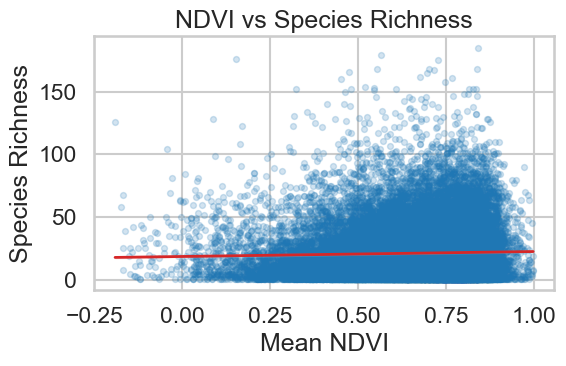

In [83]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=bio,
    x="mean_ndvi",
    y="species_richness",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
    ax=ax
)
ax.set_title("NDVI vs Species Richness")
ax.set_xlabel("Mean NDVI")
ax.set_ylabel("Species Richness")

plt.tight_layout()
plt.show()

##### This scatter plot shows the relationship between mean NDVI (vegetation index) and species richness across sampling units. Each blue point represents a site-month, and the red line is the regression trend. The plot indicates a very weak positive relationship, meaning that sites with higher NDVI tend to have slightly more species, but the effect is small and most points are clustered at lower richness values.

#### 2) NDVI vs Shannon

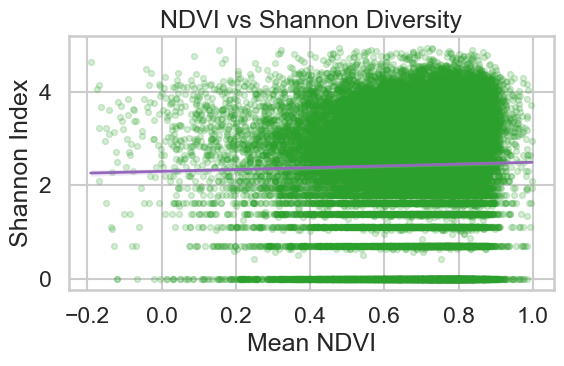

In [84]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=bio,
    x="mean_ndvi",
    y="shannon",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#2ca02c"},
    line_kws={"color": "#9467bd", "linewidth": 2},
    ax=ax
)

ax.set_title("NDVI vs Shannon Diversity")
ax.set_xlabel("Mean NDVI")
ax.set_ylabel("Shannon Index")

plt.tight_layout()
plt.show()

##### This scatter plot shows the relationship between mean NDVI and Shannon diversity across sampling units. Each green point represents a site-month, and the purple line shows the regression trend. The plot indicates a very weak positive relationship, meaning that areas with higher NDVI tend to have slightly higher diversity, but the trend is minimal and most points are concentrated at lower Shannon values.

#### 3) Boxplot: richness by land-cover class

In [85]:
order_rich = bio.groupby("landcover_mode")["species_richness"].median().sort_values(ascending=False).index

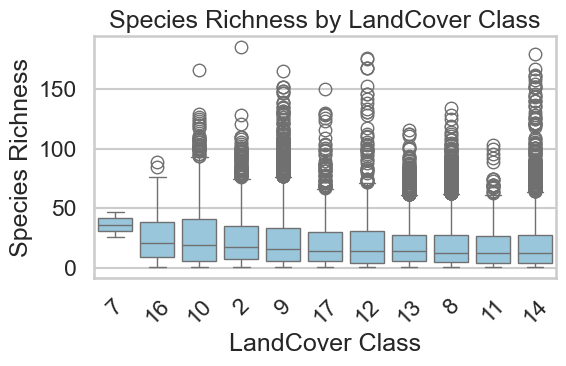

In [86]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=bio,
    x="landcover_mode",
    y="species_richness",
    order=order_rich,
    color="#8ecae6",
    ax=ax
)

ax.set_title("Species Richness by LandCover Class")
ax.set_xlabel("LandCover Class")
ax.set_ylabel("Species Richness")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### This boxplot shows that species richness varies noticeably across different land cover classes. Some classes (like 7 and 10) tend to have higher median richness, while others (such as 11, 14, and 8) generally show lower typical values. However, there is also a lot of overlap and variability within each class, with many outliers indicating that richness can still be high in less favorable habitats. Overall, the figure suggests that habitat type influences biodiversity, but it is not the only factor, since values vary widely even within the same land cover class.

In [87]:
# The line inside the box = median (middle value)
# The box edges = 25th percentile (Q1) and 75th percentile (Q3)
# So the box shows where the middle 50% of values lie
# The lines (“whiskers”) extending from the box show the typical range of values (excluding extreme ones)

# Circles (dots) represent outliers:
# Values that are much higher or lower than the normal range
# These are unusual or extreme observations

#### 4) Boxplot: Shannon by land-cover class

In [88]:
order_shan = bio.groupby("landcover_mode")["shannon"].median().sort_values(ascending=False).index

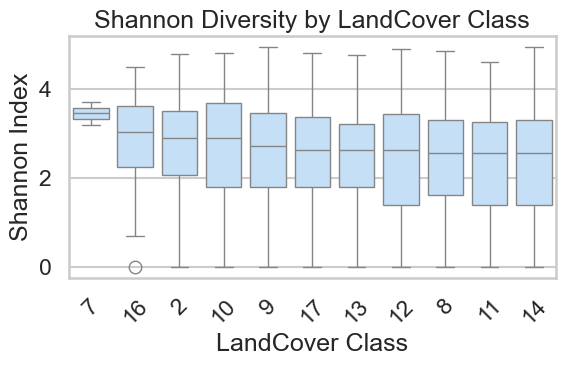

In [89]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=bio,
    x="landcover_mode",
    y="shannon",
    order=order_shan,
    color="#bde0fe",
    ax=ax
)

ax.set_title("Shannon Diversity by LandCover Class")
ax.set_xlabel("LandCover Class")
ax.set_ylabel("Shannon Index")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### This boxplot shows that Shannon diversity is fairly similar across land cover classes, with most medians around 2–3. Class 1 has a slightly higher median, but overall differences are small. The wide spread indicates high variability within each class, meaning diversity varies even within the same habitat.

### Dunn adjusted p-value heatmaps

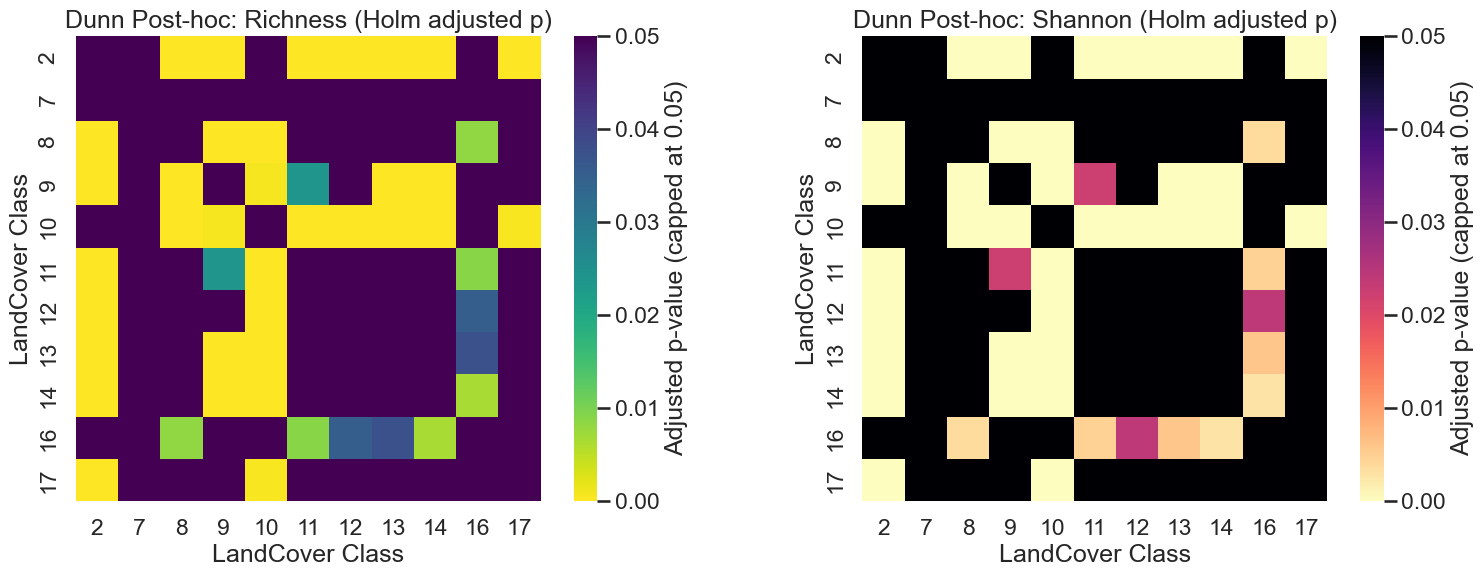

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    rich_dunn,
    cmap="viridis_r",
    vmin=0,
    vmax=0.05,
    square=True,
    cbar_kws={"label": "Adjusted p-value (capped at 0.05)"},
    ax=axes[0]
)
axes[0].set_title("Dunn Post-hoc: Richness (Holm adjusted p)")
axes[0].set_xlabel("LandCover Class")
axes[0].set_ylabel("LandCover Class")

sns.heatmap(
    shan_dunn,
    cmap="magma_r",
    vmin=0,
    vmax=0.05,
    square=True,
    cbar_kws={"label": "Adjusted p-value (capped at 0.05)"},
    ax=axes[1]
)
axes[1].set_title("Dunn Post-hoc: Shannon (Holm adjusted p)")
axes[1].set_xlabel("LandCover Class")
axes[1].set_ylabel("LandCover Class")

plt.tight_layout()
plt.show()

## Species-Level Correlations (NDVI and Land Cover)

Following the same logic as the bird–air-pollution notebook, we estimate **per-species** associations between `individualCount` and vegetation-related variables:

- **NDVI**: Pearson correlation between `NDVI` and `individualCount` within each species (linear association with greenness at observation sites).
- **Land cover**: `LandCover_Class` is a categorical code; we report **Spearman rank correlation** between class code and `individualCount` within each species (monotonic association with habitat class, treating codes as ordinal). If a species occurs under only one land-cover class in the data, the correlation is undefined (left empty).

Species with fewer than `min_records` observations are excluded for stability.

C:\Users\User\AppData\Local\Temp\ipykernel_33932\3219243820.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ndvi, _ = stats.pearsonr(sub["NDVI"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\3219243820.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_lc, _ = stats.spearmanr(sub["LandCover_Class"], sub["individualCount"])


,verbatimScientificName,n_records,NDVI,LandCover_Spearman
0,Pycnonotus cafer,43378,0.058217,-0.071617
1,Spilopelia chinensis,41311,0.044848,-0.024001
2,Acridotheres tristis,36738,-0.013242,-0.011401
3,Psittacula krameri,32501,-0.060499,0.049638
4,Halcyon smyrnensis,32413,-0.000888,0.041242
5,Argya affinis,31034,0.028826,0.057354
6,Psilopogon zeylanicus,29419,0.029339,-0.020344
7,Orthotomus sutorius,29269,-0.003847,0.038491
8,Corvus splendens,29264,-0.056756,0.058382
9,Leptocoma zeylonica,26849,0.011600,0.006260


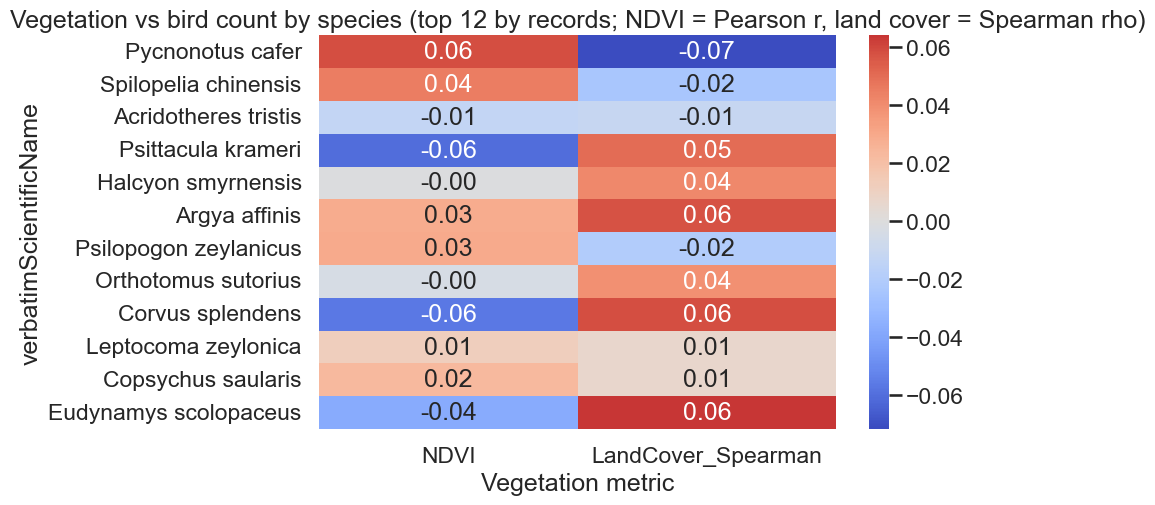

In [91]:
min_records = 30
veg_species_analysis_df = d[
    ["verbatimScientificName", "individualCount", "NDVI", "LandCover_Class"]
].dropna().copy()
veg_species_analysis_df["individualCount"] = pd.to_numeric(
    veg_species_analysis_df["individualCount"], errors="coerce"
)
veg_species_analysis_df = veg_species_analysis_df.dropna(subset=["individualCount"])

species_counts = veg_species_analysis_df["verbatimScientificName"].value_counts()
valid_species = species_counts[species_counts >= min_records].index

species_veg_rows = []
for species in valid_species:
    sub = veg_species_analysis_df[veg_species_analysis_df["verbatimScientificName"] == species]
    if len(sub) < 2:
        continue
    r_ndvi, _ = stats.pearsonr(sub["NDVI"], sub["individualCount"])
    if sub["LandCover_Class"].nunique() < 2:
        r_lc = np.nan
    else:
        r_lc, _ = stats.spearmanr(sub["LandCover_Class"], sub["individualCount"])
    species_veg_rows.append({
        "verbatimScientificName": species,
        "n_records": len(sub),
        "NDVI": r_ndvi,
        "LandCover_Spearman": r_lc,
    })

species_veg_corr_df = pd.DataFrame(species_veg_rows).sort_values(
    "n_records", ascending=False
).reset_index(drop=True)

veg_corr_cols = ["NDVI", "LandCover_Spearman"]
display(species_veg_corr_df.head(15))

top_n = min(12, len(species_veg_corr_df))
if top_n > 0:
    plt.figure(figsize=(10, max(5, top_n * 0.45)))
    heatmap_df = species_veg_corr_df.head(top_n).set_index("verbatimScientificName")[veg_corr_cols]
    sns.heatmap(heatmap_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title(
        "Vegetation vs bird count by species (top "
        + str(top_n)
        + " by records; NDVI = Pearson r, land cover = Spearman rho)"
    )
    plt.xlabel("Vegetation metric")
    plt.ylabel("verbatimScientificName")
    plt.tight_layout()
    plt.show()
else:
    print("No species met the minimum record threshold.")

#### Visual report: species-level correlation distributions

Histograms show how **Pearson *r*** (NDVI) and **Spearman rho** (land cover) vary across species. The grouped bar chart compares the top species by sample size (`n_records`).

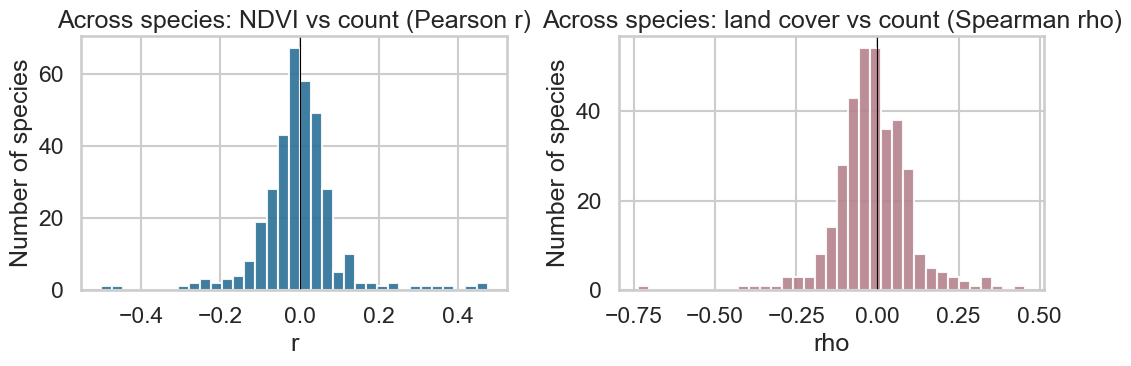

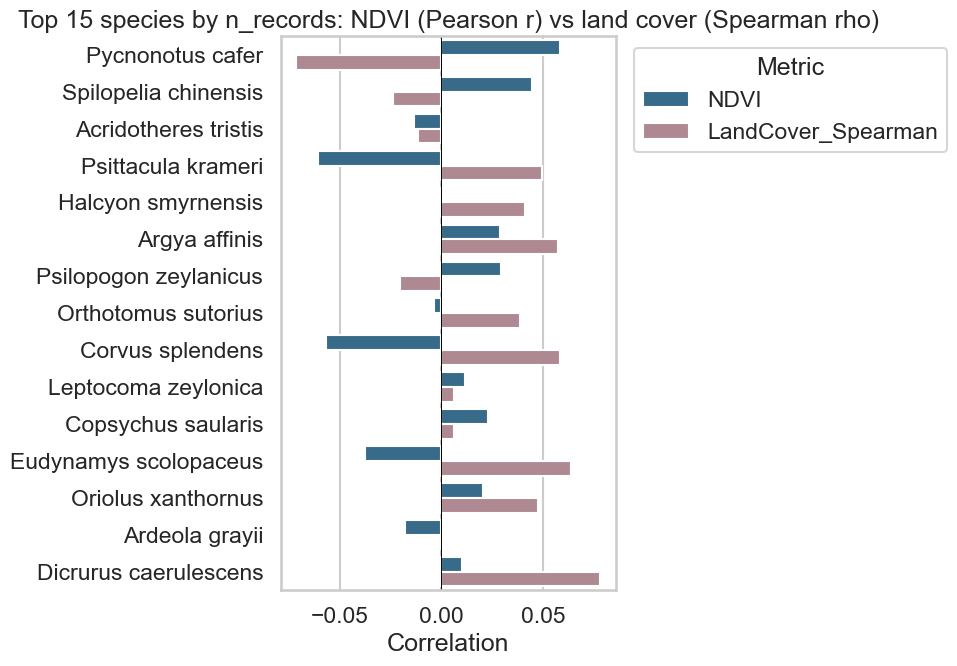

In [92]:
# Plots use species_veg_corr_df and veg_corr_cols from the cell above
if "species_veg_corr_df" in locals() and not species_veg_corr_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(species_veg_corr_df["NDVI"].dropna(), bins=35, color="#2a6f97", edgecolor="white", alpha=0.9)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_title("Across species: NDVI vs count (Pearson r)")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Number of species")

    axes[1].hist(
        species_veg_corr_df["LandCover_Spearman"].dropna(),
        bins=35,
        color="#b5838d",
        edgecolor="white",
        alpha=0.9,
    )
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title("Across species: land cover vs count (Spearman rho)")
    axes[1].set_xlabel("rho")
    axes[1].set_ylabel("Number of species")
    plt.tight_layout()
    plt.show()

    top15 = species_veg_corr_df.head(15).copy()
    plot_long = top15.melt(
        id_vars=["verbatimScientificName", "n_records"],
        value_vars=veg_corr_cols,
        var_name="metric",
        value_name="r",
    )
    order_names = top15["verbatimScientificName"].tolist()
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=plot_long,
        y="verbatimScientificName",
        x="r",
        hue="metric",
        order=order_names,
        ax=ax,
        palette={"NDVI": "#2a6f97", "LandCover_Spearman": "#b5838d"},
    )
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title("Top 15 species by n_records: NDVI (Pearson r) vs land cover (Spearman rho)")
    ax.set_xlabel("Correlation")
    ax.set_ylabel("")
    ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Run the species correlation cell first (species_veg_corr_df missing).")

### Species-level summary: rankings and responsive species

Global correlations (all rows in `veg_species_analysis_df`) are shown for context, followed by the strongest species–metric pairs and species with the largest **mean absolute** association across NDVI and land cover (where both are defined).

In [93]:
veg_corr_cols = ["NDVI", "LandCover_Spearman"]

# 1) Global (all records) associations
overall_ndvi_r = veg_species_analysis_df["NDVI"].corr(veg_species_analysis_df["individualCount"])
overall_lc_rho, overall_lc_p = stats.spearmanr(
    veg_species_analysis_df["LandCover_Class"],
    veg_species_analysis_df["individualCount"],
)
overall_veg = pd.Series(
    {
        "NDVI (Pearson r, global)": overall_ndvi_r,
        "LandCover (Spearman rho, global)": overall_lc_rho,
    },
    name="corr_with_individualCount",
)
display(overall_veg.to_frame())

# 2) Strongest species–metric pairs; 3) most "responsive" species
if "species_veg_corr_df" in locals() and not species_veg_corr_df.empty:
    long_veg = species_veg_corr_df.melt(
        id_vars=["verbatimScientificName", "n_records"],
        value_vars=veg_corr_cols,
        var_name="vegetation_metric",
        value_name="corr",
    ).dropna(subset=["corr"])

    strongest_positive = long_veg.sort_values("corr", ascending=False).head(10)
    strongest_negative = long_veg.sort_values("corr", ascending=True).head(10)

    print("Top 10 strongest positive species–vegetation correlations")
    display(strongest_positive[["verbatimScientificName", "vegetation_metric", "corr", "n_records"]])

    print("Top 10 strongest negative species–vegetation correlations")
    display(strongest_negative[["verbatimScientificName", "vegetation_metric", "corr", "n_records"]])

    species_veg_response = (
        species_veg_corr_df.set_index("verbatimScientificName")[veg_corr_cols]
        .abs()
        .mean(axis=1, skipna=True)
        .rename("mean_abs_corr")
        .sort_values(ascending=False)
        .head(10)
    )
    print("Top 10 most vegetation-responsive species (mean |correlation| across NDVI and land cover)")
    display(species_veg_response.to_frame())
else:
    print("Species-level correlation table is empty. Lower min_records if needed.")

,corr_with_individualCount
"NDVI (Pearson r, global)",-0.021511
"LandCover (Spearman rho, global)",0.080613


Top 10 strongest positive species–vegetation correlations


,verbatimScientificName,vegetation_metric,corr,n_records
323,Stercorarius pomarinus,NDVI,0.475427,53
663,Petrochelidon fluvicola,LandCover_Spearman,0.454734,84
338,Agropsar sturninus,NDVI,0.451640,37
313,Petrochelidon fluvicola,NDVI,0.437877,84
336,Stercorarius longicaudus,NDVI,0.385568,40
622,Onychoprion anaethetus,LandCover_Spearman,0.376318,345
318,Merops persicus,NDVI,0.360155,63
595,Motacilla flava,LandCover_Spearman,0.341581,544
675,Glareola pratincola,LandCover_Spearman,0.333596,53
683,Cursorius coromandelicus,LandCover_Spearman,0.322904,46


Top 10 strongest negative species–vegetation correlations


,verbatimScientificName,vegetation_metric,corr,n_records
668,Merops persicus,LandCover_Spearman,-0.736460,63
329,Anthus cervinus,NDVI,-0.502737,50
341,Calidris canutus,NDVI,-0.461364,34
695,Anous stolidus,LandCover_Spearman,-0.428598,32
687,Treron phoenicopterus,LandCover_Spearman,-0.377203,38
665,Thalasseus sandvicensis,LandCover_Spearman,-0.343402,78
688,Agropsar sturninus,LandCover_Spearman,-0.309056,37
337,Treron phoenicopterus,NDVI,-0.306734,38
689,Chroicocephalus genei,LandCover_Spearman,-0.292561,35
638,Anthus richardi,LandCover_Spearman,-0.287813,243


Top 10 most vegetation-responsive species (mean |correlation| across NDVI and land cover)


,mean_abs_corr
verbatimScientificName,
Merops persicus,0.548307
Stercorarius pomarinus,0.475427
Petrochelidon fluvicola,0.446306
Stercorarius longicaudus,0.385568
Agropsar sturninus,0.380348
Treron phoenicopterus,0.341969
Calidris canutus,0.328283
Anous stolidus,0.279724
Anthus richardi,0.266379


#### Visual report: global associations, strongest pairs, responsiveness

Bar chart of **global** correlations (all records), then the strongest species–metric pairs and mean |correlation| per species (same summaries as the tables).

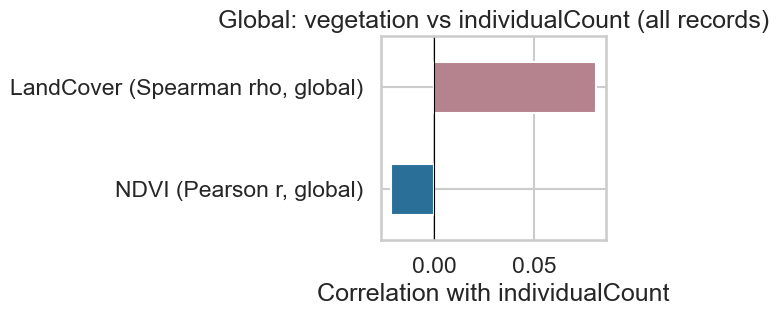

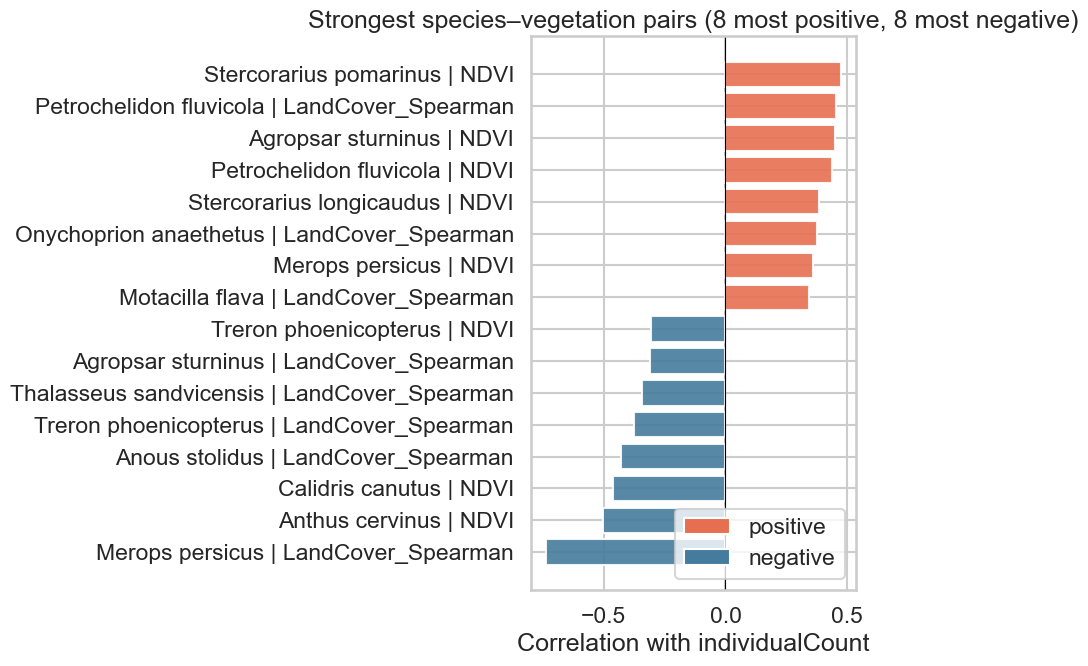

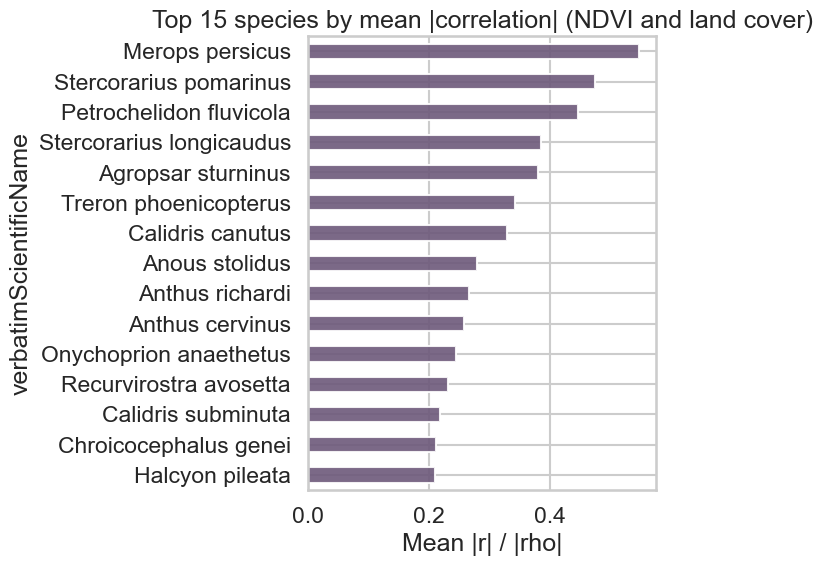

In [94]:
if "species_veg_corr_df" in locals() and not species_veg_corr_df.empty and "overall_veg" in locals():
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    overall_veg.sort_values(key=lambda s: s.abs(), ascending=True).plot(
        kind="barh", ax=ax, color=["#2a6f97", "#b5838d"]
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Global: vegetation vs individualCount (all records)")
    ax.set_xlabel("Correlation with individualCount")
    plt.tight_layout()
    plt.show()

if "species_veg_corr_df" in locals() and not species_veg_corr_df.empty and "long_veg" in locals() and len(long_veg) > 0:
    pos = long_veg.sort_values("corr", ascending=False).head(8)
    neg = long_veg.sort_values("corr", ascending=True).head(8)
    combo = pd.concat([pos.assign(side="positive"), neg.assign(side="negative")])
    combo["label"] = combo["verbatimScientificName"].str.slice(0, 32) + " | " + combo["vegetation_metric"].astype(
        str
    )
    combo = combo.sort_values("corr")
    colors = ["#457b9d" if s == "negative" else "#e76f51" for s in combo["side"]]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(combo["label"], combo["corr"], color=colors, alpha=0.9, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Strongest species–vegetation pairs (8 most positive, 8 most negative)")
    ax.set_xlabel("Correlation with individualCount")
    ax.set_ylabel("")
    from matplotlib.patches import Patch

    ax.legend(
        handles=[Patch(facecolor="#e76f51", label="positive"), Patch(facecolor="#457b9d", label="negative")],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()

if "species_veg_corr_df" in locals() and not species_veg_corr_df.empty:
    resp = (
        species_veg_corr_df.set_index("verbatimScientificName")[veg_corr_cols]
        .abs()
        .mean(axis=1, skipna=True)
        .sort_values(ascending=False)
        .head(15)
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    resp.sort_values(ascending=True).plot(kind="barh", ax=ax, color="#6d597a", alpha=0.9)
    ax.set_title("Top 15 species by mean |correlation| (NDVI and land cover)")
    ax.set_xlabel("Mean |r| / |rho|")
    plt.tight_layout()
    plt.show()
else:
    print("Run the species summary cell first.")

##### Interpretation notes

Species-specific correlations can differ from the global NDVI–count relationship because they isolate **within-species** co-variation of abundance with vegetation and land cover. Large |Spearman rho| for land cover should be read cautiously: class codes are not necessarily evenly spaced ecologically. Use these tables together with the global biodiversity and land-cover analyses above.

In [95]:
# Compact summary lines (mirrors pollution notebook "interesting facts")
if "overall_veg" in locals() and len(overall_veg) > 0:
    top_metric = overall_veg.abs().idxmax()
    top_val = overall_veg.loc[top_metric]
    print("Summary A:")
    print(
        "- Strongest global vegetation association with count: "
        + str(top_metric)
        + " = "
        + f"{top_val:.3f}"
        + "."
    )

if (
    "species_veg_corr_df" in locals()
    and not species_veg_corr_df.empty
    and "long_veg" in locals()
    and len(long_veg) > 0
):
    best_pos = long_veg.sort_values("corr", ascending=False).iloc[0]
    best_neg = long_veg.sort_values("corr", ascending=True).iloc[0]
    print("\nSummary B:")
    print(
        "- Strongest positive pair: "
        + str(best_pos["verbatimScientificName"])
        + " — "
        + str(best_pos["vegetation_metric"])
        + " (corr = "
        + f"{best_pos['corr']:.3f}"
        + ", n = "
        + str(int(best_pos["n_records"]))
        + ")."
    )
    print("\nSummary C:")
    print(
        "- Strongest negative pair: "
        + str(best_neg["verbatimScientificName"])
        + " — "
        + str(best_neg["vegetation_metric"])
        + " (corr = "
        + f"{best_neg['corr']:.3f}"
        + ", n = "
        + str(int(best_neg["n_records"]))
        + ")."
    )


Summary A:
- Strongest global vegetation association with count: LandCover (Spearman rho, global) = 0.081.

Summary B:
- Strongest positive pair: Stercorarius pomarinus — NDVI (corr = 0.475, n = 53).

Summary C:
- Strongest negative pair: Merops persicus — LandCover_Spearman (corr = -0.736, n = 63).


### Further refinement: p-values, multiple testing, and land-cover tests

We extend the species-level block in three ways:

1. **P-values and FDR** — Each species is a separate test. Raw *p*-values for NDVI (Pearson vs count) and for land cover (Spearman; Kruskal–Wallis) are adjusted with **Benjamini–Hochberg FDR** (`q`) across species. Use `q < 0.05` as a guide for "notable" species-level signals, remembering that many species still imply many tests.

2. **Log1p abundance** — Counts are skewed. **Pearson *r* between NDVI and log1p(`individualCount`)** reduces leverage of huge flocks and is reported alongside the raw-count Pearson *r*.

3. **Land cover as groups** — **Kruskal–Wallis** tests whether `individualCount` differs across `LandCover_Class` levels *within* a species (nonparametric one-way layout). This complements Spearman on class codes.

Diagnostics: distribution of NDVI *r* across species and relationship between sample size and |*r*| (small *n* species can show spuriously large correlations).

In [96]:
# --- p-values, FDR, Kruskal-Wallis, log1p NDVI (uses veg_species_analysis_df, valid_species from above) ---

def _bh_fdr(pvals):
    # Benjamini-Hochberg FDR; NaNs preserved.
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    idx = np.flatnonzero(np.isfinite(p))
    pv = p[idx]
    n = len(pv)
    if n == 0:
        return q
    order = np.argsort(pv)
    sorted_p = pv[order]
    adj = np.empty(n)
    adj[n - 1] = min(1.0, sorted_p[n - 1])
    for i in range(n - 2, -1, -1):
        adj[i] = min(sorted_p[i] * n / (i + 1), adj[i + 1])
    adj = np.minimum(adj, 1.0)
    q[idx[order]] = adj
    return q


try:
    from scipy.stats import false_discovery_control as _fdr_scipy
except ImportError:
    _fdr_scipy = None


def fdr_adjust(pvals):
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    m = np.isfinite(p)
    if not m.any():
        return out
    if _fdr_scipy is not None:
        out[m] = _fdr_scipy(p[m])
    else:
        out = _bh_fdr(pvals)
    return out


detail_rows = []
for species in valid_species:
    sub = veg_species_analysis_df[veg_species_analysis_df["verbatimScientificName"] == species]
    if len(sub) < 2:
        continue
    r_ndvi, p_ndvi = stats.pearsonr(sub["NDVI"], sub["individualCount"])
    rho_ndvi, p_ndvi_sp = stats.spearmanr(sub["NDVI"], sub["individualCount"])
    logc = np.log1p(sub["individualCount"].astype(float))
    r_ndvi_log, p_ndvi_log = stats.pearsonr(sub["NDVI"], logc)

    if sub["LandCover_Class"].nunique() < 2:
        r_lc = np.nan
        p_lc = np.nan
        kw_p = np.nan
    else:
        r_lc, p_lc = stats.spearmanr(sub["LandCover_Class"], sub["individualCount"])
        groups = [g["individualCount"].values for _, g in sub.groupby("LandCover_Class")]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) < 2:
            kw_p = np.nan
        else:
            try:
                _kw_h, kw_p = stats.kruskal(*groups)
            except ValueError:
                # e.g. all counts identical across groups (scipy raises)
                kw_p = np.nan

    detail_rows.append(
        {
            "verbatimScientificName": species,
            "n_records": len(sub),
            "NDVI": r_ndvi,
            "p_NDVI_pearson": p_ndvi,
            "NDVI_Spearman": rho_ndvi,
            "p_NDVI_spearman": p_ndvi_sp,
            "NDVI_log1p_pearson": r_ndvi_log,
            "p_NDVI_log1p": p_ndvi_log,
            "LandCover_Spearman": r_lc,
            "p_LandCover_Spearman": p_lc,
            "LandCover_kruskal_p": kw_p,
        }
    )

species_veg_detail_df = (
    pd.DataFrame(detail_rows).sort_values("n_records", ascending=False).reset_index(drop=True)
)

species_veg_detail_df["q_NDVI_pearson"] = fdr_adjust(species_veg_detail_df["p_NDVI_pearson"].values)
species_veg_detail_df["q_NDVI_log1p"] = fdr_adjust(species_veg_detail_df["p_NDVI_log1p"].values)
species_veg_detail_df["q_LandCover_Spearman"] = fdr_adjust(
    species_veg_detail_df["p_LandCover_Spearman"].values
)
species_veg_detail_df["q_LandCover_kruskal"] = fdr_adjust(
    species_veg_detail_df["LandCover_kruskal_p"].values
)

print(
    "Species count:",
    len(species_veg_detail_df),
    "| FDR q < 0.05: NDVI Pearson",
    int((species_veg_detail_df["q_NDVI_pearson"] < 0.05).sum()),
    "| NDVI log1p Pearson",
    int((species_veg_detail_df["q_NDVI_log1p"] < 0.05).sum()),
    "| LandCover Spearman",
    int((species_veg_detail_df["q_LandCover_Spearman"] < 0.05).sum()),
    "| LandCover Kruskal",
    int((species_veg_detail_df["q_LandCover_kruskal"] < 0.05).sum()),
)

show_cols = [
    "verbatimScientificName",
    "n_records",
    "NDVI",
    "p_NDVI_pearson",
    "q_NDVI_pearson",
    "NDVI_log1p_pearson",
    "q_NDVI_log1p",
    "LandCover_Spearman",
    "q_LandCover_Spearman",
    "LandCover_kruskal_p",
    "q_LandCover_kruskal",
]
display(species_veg_detail_df[show_cols].head(20))

sig_ndvi = species_veg_detail_df[species_veg_detail_df["q_NDVI_pearson"] < 0.05].sort_values(
    "NDVI", key=lambda s: s.abs(), ascending=False
)
print("Species with FDR-significant NDVI Pearson (q < 0.05), sorted by |r|:")
if len(sig_ndvi):
    display(sig_ndvi[show_cols].head(15))
else:
    print("(none)")

C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ndvi, p_ndvi = stats.pearsonr(sub["NDVI"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_ndvi, p_ndvi_sp = stats.spearmanr(sub["NDVI"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ndvi_log, p_ndvi_log = stats.pearsonr(sub["NDVI"], logc)
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_lc, p_lc = stats.spearmanr(sub["LandCover_Class"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:47: Consta

Species count: 350 | FDR q < 0.05: NDVI Pearson 116 | NDVI log1p Pearson 151 | LandCover Spearman 159 | LandCover Kruskal 273


C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ndvi, p_ndvi = stats.pearsonr(sub["NDVI"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_ndvi, p_ndvi_sp = stats.spearmanr(sub["NDVI"], sub["individualCount"])
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_ndvi_log, p_ndvi_log = stats.pearsonr(sub["NDVI"], logc)
C:\Users\User\AppData\Local\Temp\ipykernel_33932\342883180.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_lc, p_lc = stats.spearmanr(sub["LandCover_Class"], sub["individualCount"])


,verbatimScientificName,n_records,NDVI,p_NDVI_pearson,q_NDVI_pearson,NDVI_log1p_pearson,q_NDVI_log1p,LandCover_Spearman,q_LandCover_Spearman,LandCover_kruskal_p,q_LandCover_kruskal
0,Pycnonotus cafer,43378,0.058217,6.888680e-34,7.944944e-32,0.098692,2.877753e-92,-0.071617,1.683328e-48,3.642171e-131,8.352713e-130
1,Spilopelia chinensis,41311,0.044848,7.532903e-20,2.171987e-18,0.066932,1.337089e-40,-0.024001,5.321200e-06,0.000000e+00,0.000000e+00
2,Acridotheres tristis,36738,-0.013242,1.114451e-02,3.603739e-02,-0.013194,2.881101e-02,-0.011401,5.966980e-02,1.940109e-244,2.224658e-242
3,Psittacula krameri,32501,-0.060499,9.630763e-28,6.664488e-26,-0.116135,9.764805e-96,0.049638,4.719947e-18,2.989792e-159,9.349894e-158
4,Halcyon smyrnensis,32413,-0.000888,8.729199e-01,9.124782e-01,-0.007665,2.709432e-01,0.041242,9.250239e-13,8.736202e-81,1.001751e-79
5,Argya affinis,31034,0.028826,3.793455e-07,3.750101e-06,0.023147,1.996174e-04,0.057354,9.373755e-23,6.394894e-48,4.489476e-47
6,Psilopogon zeylanicus,29419,0.029339,4.824920e-07,4.511953e-06,0.031041,6.346861e-07,-0.020344,1.555070e-03,5.099209e-43,3.248385e-42
7,Orthotomus sutorius,29269,-0.003847,5.104027e-01,6.689369e-01,-0.026845,2.220034e-05,0.038491,3.022294e-10,8.800990e-126,1.780906e-124
8,Corvus splendens,29264,-0.056756,2.563097e-22,8.868315e-21,-0.232056,0.000000e+00,0.058382,2.889562e-22,0.000000e+00,0.000000e+00
9,Leptocoma zeylonica,26849,0.011600,5.734195e-02,1.358926e-01,-0.000781,9.276560e-01,0.006260,4.180519e-01,2.680484e-48,1.921014e-47


Species with FDR-significant NDVI Pearson (q < 0.05), sorted by |r|:


,verbatimScientificName,n_records,NDVI,p_NDVI_pearson,q_NDVI_pearson,NDVI_log1p_pearson,q_NDVI_log1p,LandCover_Spearman,q_LandCover_Spearman,LandCover_kruskal_p,q_LandCover_kruskal
329,Anthus cervinus,50,-0.502737,1.987013e-04,1.185356e-03,-0.508442,6.350575e-04,0.014420,9.399546e-01,1.185389e-02,1.631095e-02
323,Stercorarius pomarinus,53,0.475427,3.211838e-04,1.763962e-03,0.521945,2.581175e-04,NaN,NaN,NaN,NaN
341,Calidris canutus,34,-0.461364,6.025400e-03,2.105847e-02,-0.381593,5.794398e-02,0.195201,3.771193e-01,2.001450e-02,2.672178e-02
338,Agropsar sturninus,37,0.451640,5.016588e-03,1.886673e-02,0.527068,2.751675e-03,-0.309056,1.166054e-01,3.152211e-03,4.694201e-03
313,Petrochelidon fluvicola,84,0.437877,3.107563e-05,2.150433e-04,0.520261,2.193043e-06,0.454734,5.372726e-05,5.430348e-07,1.146037e-06
336,Stercorarius longicaudus,40,0.385568,1.400808e-02,4.289201e-02,0.426932,1.664141e-02,NaN,NaN,NaN,NaN
318,Merops persicus,63,0.360155,3.739022e-03,1.515051e-02,0.360155,1.115260e-02,-0.736460,4.413426e-11,6.675553e-09,1.652079e-08
295,Calidris subminuta,191,0.311447,1.156625e-05,8.893162e-05,0.333694,1.233633e-05,-0.125841,1.454431e-01,2.743276e-02,3.534408e-02
297,Clamator coromandus,160,-0.257328,1.020007e-03,4.834554e-03,-0.237074,8.140768e-03,0.078862,4.270921e-01,7.776260e-08,1.759890e-07
294,Ichthyaetus ichthyaetus,208,-0.248271,2.994031e-04,1.670863e-03,-0.200915,1.097321e-02,0.039315,6.635450e-01,8.433116e-01,8.532329e-01


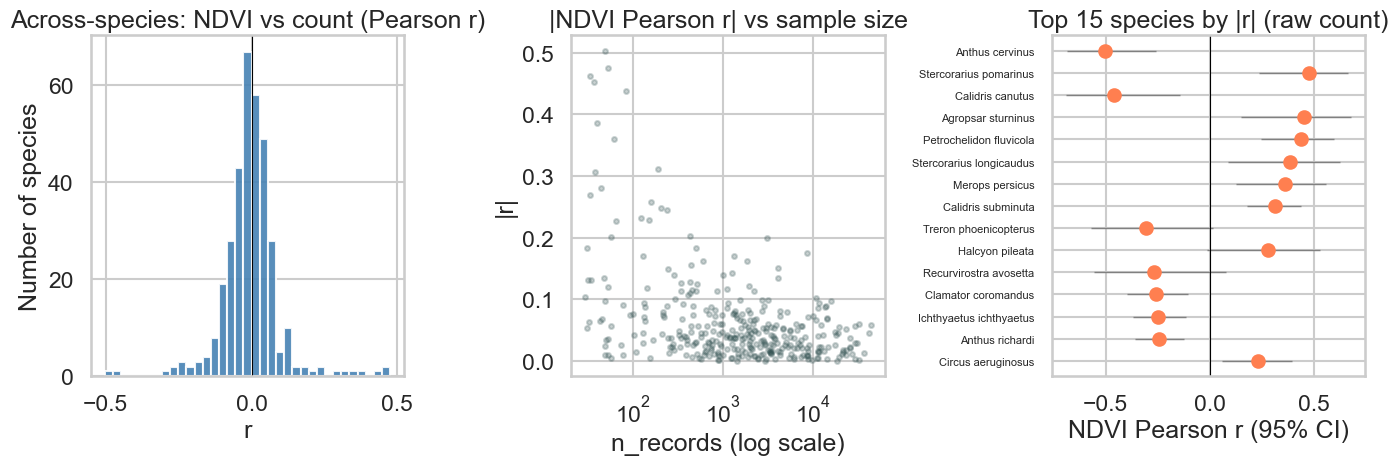

In [97]:
# Fisher z approximate 95% CI for Pearson r; forest plot for species with strongest |NDVI r|


def pearson_r_ci(r, n, alpha=0.05):
    if not np.isfinite(r) or n < 4:
        return np.nan, np.nan
    z = np.arctanh(np.clip(r, -0.999999, 0.999999))
    se = 1.0 / np.sqrt(n - 3)
    zc = stats.norm.ppf(1 - alpha / 2)
    lo, hi = np.tanh(z - zc * se), np.tanh(z + zc * se)
    return lo, hi


top_forest = species_veg_detail_df.assign(abs_ndvi=lambda x: x["NDVI"].abs()).nlargest(15, "abs_ndvi")
cis = [pearson_r_ci(r, int(n)) for r, n in zip(top_forest["NDVI"], top_forest["n_records"])]
top_forest = top_forest.copy()
top_forest["ci_lo"] = [c[0] for c in cis]
top_forest["ci_hi"] = [c[1] for c in cis]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].hist(species_veg_detail_df["NDVI"].dropna(), bins=35, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Across-species: NDVI vs count (Pearson r)")
axes[0].set_xlabel("r")
axes[0].set_ylabel("Number of species")

axes[1].scatter(
    species_veg_detail_df["n_records"],
    species_veg_detail_df["NDVI"].abs(),
    alpha=0.25,
    s=12,
    color="darkslategray",
)
axes[1].set_xscale("log")
axes[1].set_title("|NDVI Pearson r| vs sample size")
axes[1].set_xlabel("n_records (log scale)")
axes[1].set_ylabel("|r|")

y_pos = np.arange(len(top_forest))
axes[2].hlines(y_pos, top_forest["ci_lo"], top_forest["ci_hi"], color="gray", linewidth=1)
axes[2].scatter(top_forest["NDVI"], y_pos, color="coral", zorder=3)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(top_forest["verbatimScientificName"], fontsize=8)
axes[2].set_xlabel("NDVI Pearson r (95% CI)")
axes[2].set_title("Top 15 species by |r| (raw count)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

##### How to read the refinement

- **FDR *q*** controls the expected fraction of false positives among species flagged as significant; it does not remove confounding (e.g. geography mixed with vegetation).
- **Kruskal–Wallis *p*** / **q** asks whether counts differ across land-cover *categories* for that species; it does not assume class codes are equally spaced.
- **log1p** NDVI correlations that stay large when raw-count *r* shrinks suggest sensitivity to skew; compare `NDVI` vs `NDVI_log1p_pearson` in `species_veg_detail_df`.
- The **sample-size scatter** shows that rare species can show large |*r*| by chance; prefer interpretations supported by adequate `n_records` and FDR.